## I. Loading and Visualization of datasets


**Installing libraries**

In [21]:
%pip install -q matplotlib pandas torch torchvision

Note: you may need to restart the kernel to use updated packages.


### A. Occupancy Map

#### 1. creating / loading dataset 

In [22]:
import numpy as np
import torch

×32 maps, exactly 3 obstacles


We generate a 1000 binary matrices, 0 = free space, 1 = obstacle

We added walls equal to 1 

In [23]:
def make_maps(n=5000, size=64):
    maps = []
    for _ in range(n):
        m = np.zeros((size, size), dtype=np.float32)

        # Outer walls
        m[[0, -1], :] = 1
        m[:, [0, -1]] = 1

        # Random rectangular obstacles
        for _ in range(np.random.randint(2, 7)):
            w, h = np.random.randint(4, 15, size=2)
            x = np.random.randint(2, size - w - 2)
            y = np.random.randint(2, size - h - 2)
            m[y:y+h, x:x+w] = 1

        maps.append(m)

    return torch.tensor(np.array(maps)).unsqueeze(1)


In [24]:
X = make_maps()

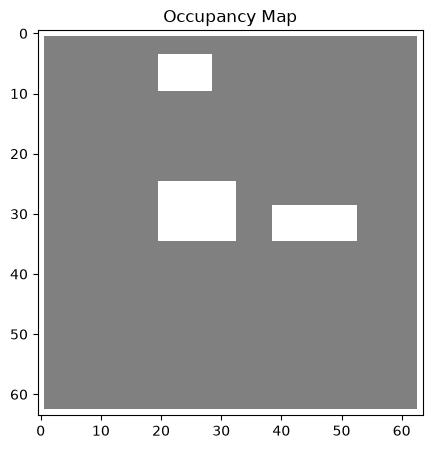

In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 0 = free space, 1 = obstacle
cmap = ListedColormap(["grey", "white"])

plt.figure(figsize=(5, 5))
plt.imshow(X[0, 0], cmap=cmap)
plt.title("Occupancy Map")
plt.axis("on")
plt.show()

### B. BOP-format T-LESS dataset

In [26]:
from torch.utils.data import Dataset
from torchvision import transforms
from pathlib import Path


In [27]:
class TLessDataset(Dataset):
    def __init__(self, root, objects=(1, 2, 3)):
        self.files = []

        for obj in objects:
            folder = Path(root) / f"{obj:02d}" / "rgb"
            self.files += [(f, obj) for f in folder.glob("*.png")]

        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        file, label = self.files[i]
        image = Image.open(file).convert("RGB")
        return self.transform(image), label

#### 2. Loading dataset into pytorch DataLoader

We start by loading data into TensorDataset function, which takes a data matrix and adds indexes to make it compatible with pytorch
Second, we load the indexed dataset into DataLoader, which shuffles our dataset and cuts into batches, ready to go into our model 

In [28]:
from PIL import Image

In [29]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TLessDataset(
    "../Data/T-LESS/t-less_v2_train_primesense",
    objects=(1, 2, 3)
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

x, labels = next(iter(loader))

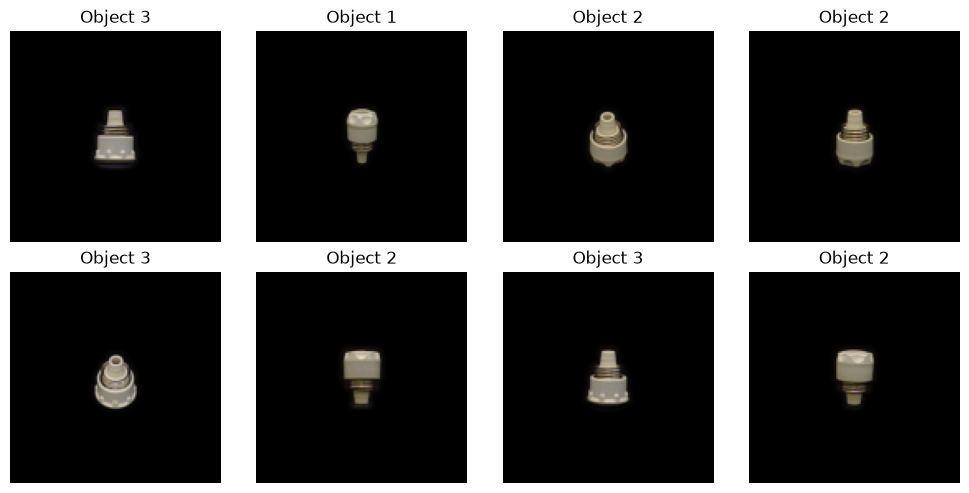

In [30]:
import random

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for ax in axes.flat:
    i = random.randrange(len(dataset))
    image, label = dataset[i]

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"Object {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### II. Initializing VAE

We will move to GPU for faster speeds

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
from torch import nn

In [33]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # -------------------------
        # ENCODER
        # -------------------------
        # Input shape: [3, 128, 128]
        # Four downsampling blocks: 128 -> 64 -> 32 -> 16 -> 8.
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten()
        )

        # -------------------------
        # LATENT DISTRIBUTION
        # -------------------------
        # A VAE does not encode an image into one fixed point.
        # It predicts the mean and variance of a Gaussian distribution.

        self.encoded_size = 256 * 8 * 8
        self.fc_mu = nn.Linear(self.encoded_size, latent_dim)

        # We predict log(variance) because it is more numerically stable.
        self.fc_logvar = nn.Linear(self.encoded_size, latent_dim)

        # -------------------------
        # DECODER INPUT
        # -------------------------
        # Expand the small latent vector back into enough features
        # to reconstruct an image.

        self.fc_decode = nn.Linear(latent_dim, self.encoded_size)

        # -------------------------
        # DECODER
        # -------------------------
        self.decoder = nn.Sequential(

            nn.Unflatten(dim=1, unflattened_size=(256, 8, 8)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            # Keep reconstructed pixel values between 0 and 1
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode image into features
        h = self.encoder(x)

        # Get mean and log-variance
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        # Reparameterization trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps

        # Decode latent vector back into image
        x_hat = self.fc_decode(z)
        x_hat = self.decoder(x_hat)

        return x_hat, mu, logvar

### III. Model Training

In [34]:
model = VAE(latent_dim=128).to(device)

Adam updates the model weights to reduce the VAE loss. Conceptually:
θ  ←    θ  −  learning rate × Adam-adjusted gradient

For a VAE, lr=1e-3 is a good simple starting point, lr is the loss ratio.

In [35]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

Then, we need the VAE loss, usually     :
                L = L- reconstruction +   L_KL

In [36]:
def vae_loss(x_hat, x, mu, logvar, beta=1e-4):
    recon_loss = nn.functional.mse_loss(x_hat, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp(), dim=1
    ))

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

#### Training Loop for our VAE

In [37]:
epochs = 50
target_beta = 1e-4
kl_warmup_epochs = 10

In [38]:
for epoch in range(epochs):
    model.train()
    running_total = 0.0
    running_recon = 0.0
    running_kl = 0.0

    # Gradually introduce latent-space regularization.
    beta = target_beta * min(1.0, (epoch + 1) / kl_warmup_epochs)

    for images, _ in loader:
        images = images.to(device)
        optimizer.zero_grad()

        x_hat, mu, logvar = model(images)

        loss, recon_loss, kl_loss = vae_loss(
            x_hat, images, mu, logvar, beta=beta
        )

        loss.backward()
        optimizer.step()

        running_total += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()

    n_batches = len(loader)
    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"loss: {running_total / n_batches:.4f} | "
        f"recon: {running_recon / n_batches:.4f} | "
        f"KL: {running_kl / n_batches:.4f} | beta: {beta:.1e}"
    )

Epoch 01/50 | loss: 0.0419 | recon: 0.0411 | KL: 73.9922 | beta: 1.0e-05
Epoch 02/50 | loss: 0.0034 | recon: 0.0026 | KL: 40.1841 | beta: 2.0e-05
Epoch 03/50 | loss: 0.0018 | recon: 0.0014 | KL: 13.0494 | beta: 3.0e-05
Epoch 04/50 | loss: 0.0015 | recon: 0.0011 | KL: 9.1926 | beta: 4.0e-05
Epoch 05/50 | loss: 0.0013 | recon: 0.0009 | KL: 7.2428 | beta: 5.0e-05
Epoch 06/50 | loss: 0.0012 | recon: 0.0008 | KL: 5.9979 | beta: 6.0e-05
Epoch 07/50 | loss: 0.0011 | recon: 0.0008 | KL: 5.1768 | beta: 7.0e-05
Epoch 08/50 | loss: 0.0011 | recon: 0.0007 | KL: 4.6839 | beta: 8.0e-05
Epoch 09/50 | loss: 0.0011 | recon: 0.0007 | KL: 4.3425 | beta: 9.0e-05
Epoch 10/50 | loss: 0.0011 | recon: 0.0007 | KL: 4.3462 | beta: 1.0e-04
Epoch 11/50 | loss: 0.0011 | recon: 0.0006 | KL: 4.2472 | beta: 1.0e-04
Epoch 12/50 | loss: 0.0010 | recon: 0.0006 | KL: 4.2030 | beta: 1.0e-04
Epoch 13/50 | loss: 0.0010 | recon: 0.0006 | KL: 4.1300 | beta: 1.0e-04
Epoch 14/50 | loss: 0.0010 | recon: 0.0006 | KL: 4.2008 | bet

### IV. Reconstructing Samples in the training set

To obtain stable reconstructions, we decode the mean of each image's latent distribution instead of drawing a random latent sample.

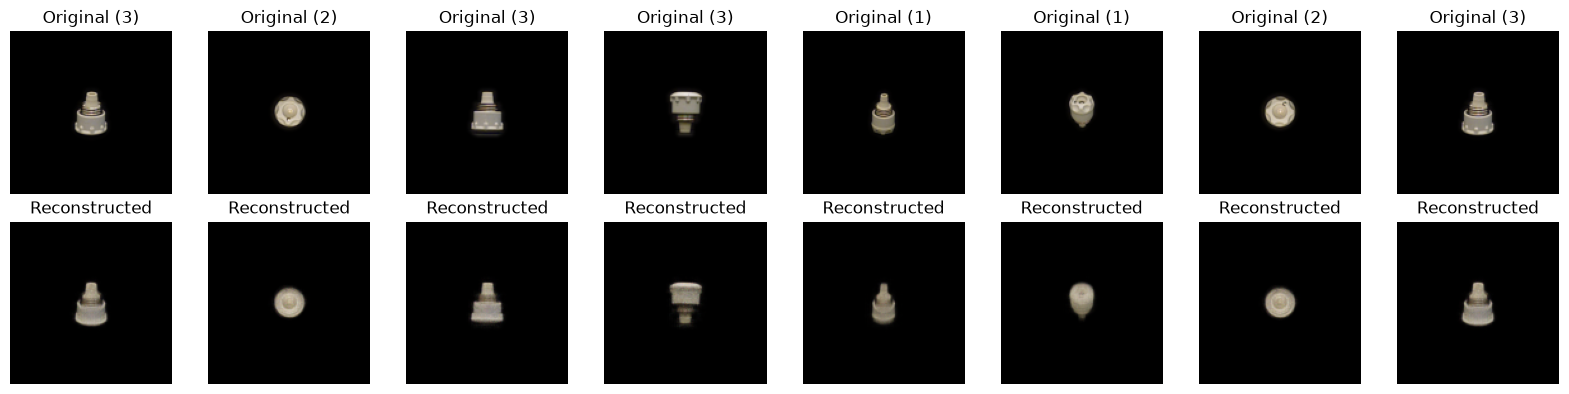

In [39]:
model.eval()
model_device = next(model.parameters()).device

# Take one batch from the training set.
images, labels = next(iter(loader))
images = images.to(model_device)

with torch.no_grad():
    features = model.encoder(images)
    mu = model.fc_mu(features)
    reconstructions = model.decoder(model.fc_decode(mu))

n_samples = min(8, images.size(0))
fig, axes = plt.subplots(2, n_samples, figsize=(2 * n_samples, 4), squeeze=False)

for i in range(n_samples):
    original = images[i].detach().cpu().permute(1, 2, 0)
    reconstructed = reconstructions[i].detach().cpu().permute(1, 2, 0)

    axes[0, i].imshow(original.clamp(0, 1))
    axes[0, i].set_title(f"Original ({labels[i].item()})")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed.clamp(0, 1))
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()